<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/15_DecisionTree_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree로 TSLA 방향성 예측 (분류)
이 노트북은 다음 거래일의 **상승/하락(이진 분류)**을 예측합니다.
시계열에서는 **시간 순서 보존**과 **정보누수 방지**가 핵심입니다.


### 🔍 Decision Tree 노드 내부 지표 및 수학적 원리

시각화된 나무의 각 사각형(노드)에 적힌 값들은 학습 데이터의 통계치이며, 다음과 같은 수학적 원리로 계산됩니다.

#### 1. 지니 불순도 (Gini Impurity)
노드 내에 서로 다른 클래스(상승/하락)가 얼마나 섞여 있는지를 측정합니다.
- **수식**: $Gini = 1 - \sum (P_i)^2$
- **의미**: **0.0**에 가까울수록 한쪽 방향으로 잘 모인 '순수한' 상태입니다. 모델은 이 불순도를 가장 많이 낮추는(정보 이득 최대화) 기준을 찾아 데이터를 분할합니다.

#### 2. Samples (샘플 수)
현재 노드에 도달한 데이터의 총 개수입니다. 샘플 수가 너무 적은 노드에서 내린 결정은 통계적 신뢰도가 낮아 과적합(Overfitting)의 위험이 있습니다.

#### 3. Value [하락 개수, 상승 개수] & Class
해당 노드에 포함된 실제 '하락(0)'과 '상승(1)'의 개수입니다. 더 많은 개수를 차지하는 쪽이 해당 노드의 최종 예측인 **Class(Up/Down)**가 됩니다.

### 🧠 과적합 방지 (Pruning)
나무가 너무 깊어지면 학습 데이터의 노이즈까지 학습하여 실전 성능이 떨어집니다. 이를 방지하기 위해 `max_depth`(최대 깊이)와 `min_samples_leaf`(잎 노드 최소 샘플 수)를 설정하여 적절한 수준에서 가지치기를 수행합니다.

## 0) 환경 준비
```bash
pip install yfinance
```


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)


## 1) 데이터 수집 (2025-03-30 ~ 2026-03-30, 최근 1년)


In [3]:
# 데이터 수집 (최근 1년)
df = yf.download("TSLA", start="2025-03-30", end="2026-03-30", auto_adjust=True, progress=False).reset_index()
print("Rows:", len(df))
df.head()


Rows: 247


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2025-03-31,259.160004,260.559998,243.360001,249.309998,134008900
1,2025-04-01,268.459991,277.450012,259.250000,263.799988,146486900
2,2025-04-02,282.760010,284.989990,251.270004,254.600006,212787800
3,2025-04-03,267.279999,276.299988,261.510010,265.290009,136174300
4,2025-04-04,239.429993,261.000000,236.000000,255.380005,181229400


## 2) 특징 생성 (Feature Engineering)

### 🔍 피처(Feature) 상세 설명

모델의 예측 성능을 높이기 위해 사용된 7가지 기술적 지표의 의미는 다음과 같습니다.

1.  **`ret_lag1` ~ `ret_lag10` (Lagged Returns)**:
    *   **설명**: 각각 1일 전, 2일 전, 3일 전, 5일 전, 10일 전의 주가 수익률입니다.
    *   **의도**: 과거의 수익률 패턴이 내일의 방향성에 영향을 주는지 학습합니다 (예: 어제 올랐으면 오늘도 오를까?).

2.  **`ma_gap` (MA Cross Over Distance)**:
    *   **계산**: `(5일 이동평균 / 20일 이동평균) - 1.0`
    *   **설명**: 단기 평단가(5일)와 중기 평단가(20일) 사이의 이격도입니다.
    *   **의도**: 단기 추세가 장기 추세 대비 얼마나 과열되었는지 또는 골든/데드크로스 근처에 있는지를 나타냅니다.

3.  **`vol10` (Rolling Volatility)**:
    *   **계산**: 최근 10일간 수익률의 표준편차(Standard Deviation)
    *   **설명**: 최근 시장의 변동성(위험도)을 측정합니다.
    *   **의도**: 시장이 불안정한 상태(고변동성)인지 안정적인 상태(저변동성)인지에 따라 상승 확률이 달라지는지 확인합니다.

In [4]:
# 특징(Feature) 생성: 과거 정보만 사용
df['ret1'] = df['Close'].pct_change()

for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0
df['vol10'] = df['ret1'].rolling(10).std()

df = df.dropna().reset_index(drop=True)
print("After features rows:", len(df))


After features rows: 228


## 3) 타깃/분할(시간 순서 보존)


In [5]:
# 타깃: 다음날 상승(1) / 하락(0)
df['ret_next'] = df['Close'].pct_change().shift(-1)
df['y_bin'] = (df['ret_next'] > 0).astype(int)
df = df.dropna().reset_index(drop=True)

features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features]
y = df['y_bin']

# 시간 순서 보존 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (181, 7) Test: (46, 7)


## 4) 모델: Decision Tree
- 비선형 분할을 통해 규칙 기반 분류를 수행합니다.
- 과적합이 쉬우므로 `max_depth` 등으로 제어합니다.


In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 모델 정의 및 학습
model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## 5) 평가 및 지표 설명

### 📊 주요 평가지표 상세 설명

1. **Accuracy (정확도)**
   - 수식: $\frac{TP + TN}{TP + TN + FP + FN}$
   - 의미: 전체 예측 중 맞춘 비율입니다. 하지만 금융 데이터처럼 클래스 불균형이 있을 땐 착시가 생길 수 있습니다.

2. **ROC-AUC**
   - 의미: 모델이 상승(1)과 하락(0)을 얼마나 잘 '구분'하는지 나타내는 지표입니다. 1에 가까울수록 판별력이 높고, 0.5면 무작위 추측과 같습니다.

3. **Precision (정밀도)**
   - 수식: $\frac{TP}{TP + FP}$
   - 의미: '상승'이라고 예측한 것 중 실제로 상승한 비율입니다. (틀린 매수 신호를 줄이는 지표)

4. **Recall (재현율)**
   - 수식: $\frac{TP}{TP + FN}$
   - 의미: 실제 '상승'한 날들 중 모델이 상승이라고 맞춘 비율입니다. (기회를 놓치지 않는 지표)

Accuracy: 0.5435
ROC-AUC : 0.5549

Classification report:
              precision    recall  f1-score   support

           0     0.6000    0.1364    0.2222        22
           1     0.5366    0.9167    0.6769        24

    accuracy                         0.5435        46
   macro avg     0.5683    0.5265    0.4496        46
weighted avg     0.5669    0.5435    0.4595        46



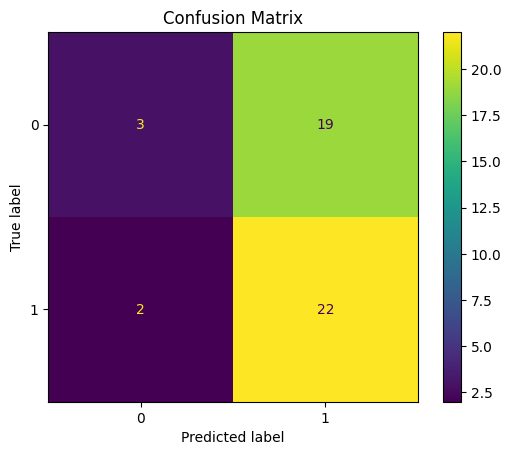

In [7]:
# 평가
y_pred = model.predict(X_test)
# 확률 예측이 가능한 모델이면 AUC도 계산
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
else:
    y_proba = None
    auc = None

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
if auc is not None:
    print(f"ROC-AUC : {auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()


## ✅ 모델 해석: Decision Tree 원리

### 🌳 Decision Tree(의사결정나무)의 작동 방식
1. **데이터 분할**: 스무고개처럼 특정 조건(예: `ma_gap > 0.02`)을 기준으로 데이터를 나눕니다.
2. **정보 이득(Information Gain)**: 불순도(Gini 지수)를 가장 많이 낮추는 변수를 선택하여 최상단(Root Node)에 배치합니다.
3. **해석력**: '만약 어제 수익률이 낮고 변동성이 낮다면 상승할 확률이 높다'와 같은 직관적인 규칙을 제공합니다.

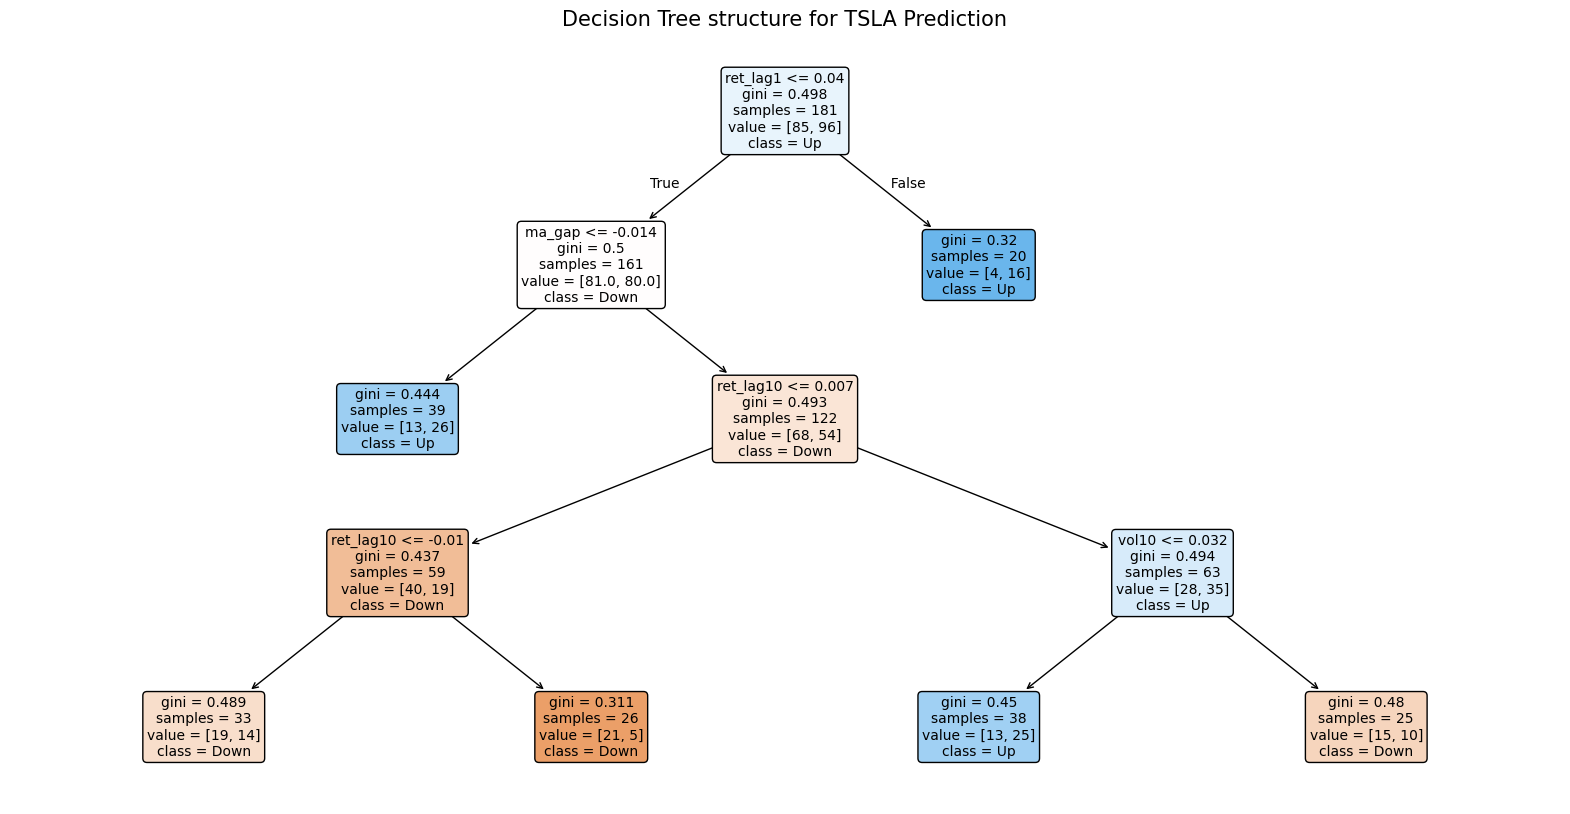

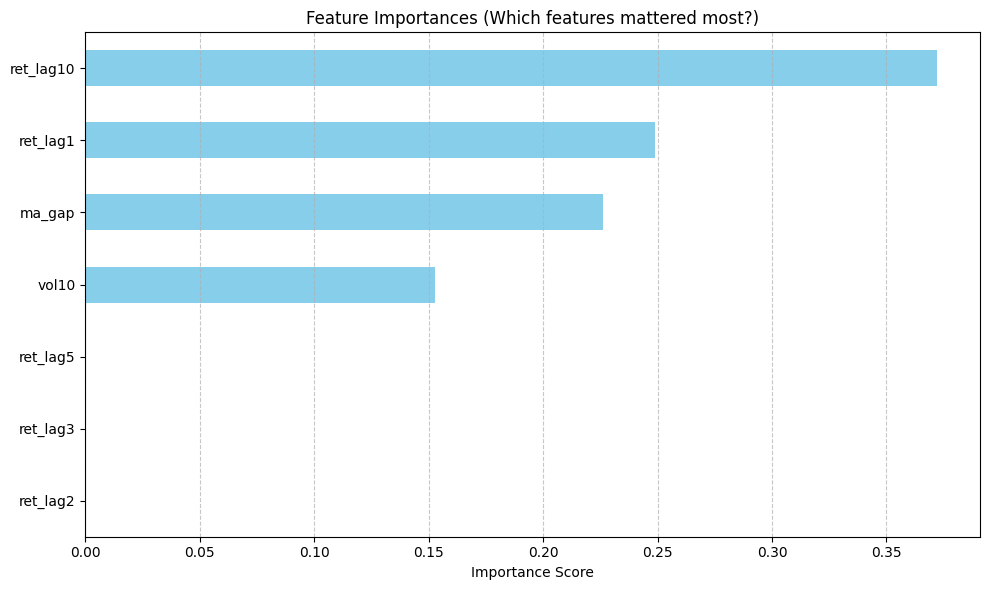

In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd

# 1. Decision Tree 시각화
plt.figure(figsize=(20, 10))
plot_tree(model,
          feature_names=features,
          class_names=['Down', 'Up'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree structure for TSLA Prediction', fontsize=15)
plt.show()

# 2. 피처 중요도(Feature Importance) 시각화
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importances (Which features mattered most?)')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
import numpy as np

# 예측된 값 (0: 하락, 1: 상승)의 개수 계산
prediction_counts = np.bincount(y_pred)

# 예측 결과 출력
print(f"Predicted Down (하락): {prediction_counts[0] if len(prediction_counts) > 0 else 0} 건")
print(f"Predicted Up (상승): {prediction_counts[1] if len(prediction_counts) > 1 else 0} 건")

Predicted Down (하락): 5 건
Predicted Up (상승): 41 건


In [10]:
# X 데이터프레임의 마지막 행을 사용하여 다음 거래일 예측에 필요한 특징을 가져옵니다.
last_day_features = X.iloc[-1].values.reshape(1, -1)

# 모델을 사용하여 예측을 수행합니다.
next_day_prediction = model.predict(last_day_features)

# 예측 결과를 해석합니다.
prediction_label = "상승 (Up)" if next_day_prediction[0] == 1 else "하락 (Down)"

# 예측 날짜를 계산합니다 (단순히 마지막 날짜 + 1일로 가정).
# 실제 거래일은 휴장일을 제외해야 하지만, 여기서는 단순화를 위해 +1일로 표시합니다.
last_date_in_df = df['Date'].iloc[-1]
predicted_date = last_date_in_df + pd.Timedelta(days=1)

print(f"다음 거래일 예측 (날짜: {predicted_date.strftime('%Y-%m-%d')}): {prediction_label}")

다음 거래일 예측 (날짜: 2026-03-24): 상승 (Up)


## ✅ 요약(3줄)
1) 분류는 ‘가격’을 맞추는 것이 아니라 ‘방향(Up/Down)’을 예측합니다.
2) 시계열에서는 **시간 분할**과 **누수 방지**가 성능보다 먼저입니다.
3) 정확도만 보지 말고 AUC/혼동행렬/기준선과 함께 해석하세요.
